# Projet Deep Learning -  Safe Drone Landing with YOLO

>Picard Sarah - Sermet Eline 


In [32]:
!pip install ultralytics pyyaml


## 2. Imports

In [33]:
import os
import glob
from pathlib import Path
import yaml
from ultralytics import YOLO


## 3. Configuration


In [34]:
DATA_YAML = r"C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\data.yaml"

MODEL_NAME = "yolov8n.pt"
EPOCHS = 50
IMGSZ = 640
BATCH = 16

TAU_CONF = 0.50
TAU_AREA = 0.03


## 4. Fonctions utiles

In [35]:
def load_yaml(yaml_path):
    with open(yaml_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def to_abs_path(base_dir, value):
    p = Path(value)
    if p.is_absolute():
        return str(p)
    return str((base_dir / p).resolve())

def create_fixed_yaml(data_yaml_path):
    data_yaml_path = Path(data_yaml_path).resolve()
    cfg = load_yaml(data_yaml_path)
    base_dir = data_yaml_path.parent

    fixed_cfg = dict(cfg)
    fixed_cfg["train"] = to_abs_path(base_dir, cfg["train"])
    fixed_cfg["val"] = to_abs_path(base_dir, cfg["val"])
    if "test" in cfg:
        fixed_cfg["test"] = to_abs_path(base_dir, cfg["test"])
    fixed_cfg["path"] = str(base_dir)

    fixed_yaml = base_dir / "data_fixed.yaml"
    with open(fixed_yaml, "w", encoding="utf-8") as f:
        yaml.safe_dump(fixed_cfg, f, sort_keys=False, allow_unicode=True)

    return fixed_yaml, fixed_cfg

def landing_decision(result, tau_conf=0.50, tau_area=0.03):
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return "NOT SAFE", 0.0, 0.0

    h, w = result.orig_shape
    image_area = w * h

    best_conf = 0.0
    best_area_ratio = 0.0

    for b in boxes:
        conf = float(b.conf[0])
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        box_area = max(0, x2 - x1) * max(0, y2 - y1)
        area_ratio = box_area / image_area

        if conf > best_conf:
            best_conf = conf
            best_area_ratio = area_ratio

    if best_conf >= tau_conf and best_area_ratio >= tau_area:
        return "SAFE", best_conf, best_area_ratio
    return "NOT SAFE", best_conf, best_area_ratio


## 5. Vérification du `data.yaml` et création d'un YAML corrigé

In [36]:
fixed_yaml, fixed_cfg = create_fixed_yaml(DATA_YAML)

print("YAML corrigé :", fixed_yaml)
print()
print("Contenu du YAML corrigé :")
print(fixed_cfg)


YAML corrigé : C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\data_fixed.yaml

Contenu du YAML corrigé :
{'train': 'C:\\Users\\sarah\\Desktop\\Elisa 5\\projet deep learning\\landing_pad.v2i.yolov8\\train\\images', 'val': 'C:\\Users\\sarah\\Desktop\\Elisa 5\\projet deep learning\\landing_pad.v2i.yolov8\\valid\\images', 'test': 'C:\\Users\\sarah\\Desktop\\Elisa 5\\projet deep learning\\landing_pad.v2i.yolov8\\test\\images', 'nc': 1, 'names': ['landing_pad'], 'roboflow': {'workspace': 'elines-workspace', 'project': 'landing_pad-ckom1', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/elines-workspace/landing_pad-ckom1/dataset/2'}, 'path': 'C:\\Users\\sarah\\Desktop\\Elisa 5\\projet deep learning\\landing_pad.v2i.yolov8'}


## 6. Vérification rapide du dataset

In [37]:
for split in ["train", "val", "test"]:
    if split in fixed_cfg:
        n_files = len(list(Path(fixed_cfg[split]).glob("*")))
        print(f"{split}: {n_files} fichiers")


train: 121 fichiers
val: 63 fichiers
test: 56 fichiers


## 7. Charger le modèle YOLO

In [38]:
model = YOLO(MODEL_NAME)
print("Modèle chargé :", MODEL_NAME)


Modèle chargé : yolov8n.pt


## 8. Entraînement

In [39]:
results = model.train(
    data=DATA_YAML,
    epochs=30,
    imgsz=512,
    batch=8
)

Ultralytics 8.4.21  Python-3.10.18 torch-2.8.0+cu126 CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimi

## 9. Charger le meilleur modèle

In [40]:
from pathlib import Path

list(Path(".").rglob("best.pt"))

[WindowsPath('runs/detect/train/weights/best.pt'),
 WindowsPath('runs/detect/train2/weights/best.pt')]

In [41]:
best_model_path = Path("runs/detect/train/weights/best.pt")
print("Meilleur modèle :", best_model_path)

best_model = YOLO(str(best_model_path))

Meilleur modèle : runs\detect\train\weights\best.pt


## 10. Validation

In [42]:
metrics = best_model.val()
metrics


Ultralytics 8.4.21  Python-3.10.18 torch-2.8.0+cu126 CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 57.519.3 MB/s, size: 10.7 KB)
val: Scanning C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\valid\labels.cache... 63 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3s/it 5.2s1.8s
                   all         63         47      0.886      0.828      0.917      0.715
Speed: 1.0ms preprocess, 56.2ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to C:\Users\sarah\Desktop\Elisa 5\projet deep learning\runs\detect\val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000021281A2ACE0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

## 11. Prédictions sur le dossier test

In [43]:
test_path = r"C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\test\images"

print("Dossier utilisé pour les prédictions :", test_path)

best_model.predict(source=test_path, save=True, conf=0.25)

print("Prédictions sauvegardées dans le dossier runs.")

Dossier utilisé pour les prédictions : C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\test\images

image 1/56 C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\test\images\Capture-d-ecran-2026-02-26-120613_png.rf.67065c4f3b159809d2cdf536a9157d55.jpg: 416x416 1 landing_pad, 110.4ms
image 2/56 C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\test\images\Capture-d-ecran-2026-02-26-120632_png.rf.f162b14f656290ab6413252c12f21d4e.jpg: 416x416 1 landing_pad, 61.4ms
image 3/56 C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\test\images\Capture-d-ecran-2026-02-26-120715_png.rf.5df31089475e53a288b8cf6900579446.jpg: 416x416 (no detections), 60.1ms
image 4/56 C:\Users\sarah\Desktop\Elisa 5\projet deep learning\landing_pad.v2i.yolov8\test\images\Capture-d-ecran-2026-02-26-120758_png.rf.f3b0c4550eeced566917428d38bbe63f.jpg: 416x416 1 landing_pad, 56.6ms
image 5/56 C:\Users\sarah\Desktop\Elisa 5\

## 12. SAFE / NOT SAFE sur quelques images

In [44]:
sample_images = sorted(glob.glob(os.path.join(test_path, "*")))[:10]
results = best_model.predict(source=sample_images, conf=0.01, save=False, verbose=False)

for i, r in enumerate(results):
    decision, conf, area = landing_decision(r, tau_conf=TAU_CONF, tau_area=TAU_AREA)
    print(f"Image {i+1}: decision={decision}, conf={conf:.3f}, area_ratio={area:.4f}")


Image 1: decision=SAFE, conf=0.722, area_ratio=0.0769
Image 2: decision=NOT SAFE, conf=0.345, area_ratio=0.0672
Image 3: decision=NOT SAFE, conf=0.203, area_ratio=0.0727
Image 4: decision=SAFE, conf=0.564, area_ratio=0.0767
Image 5: decision=NOT SAFE, conf=0.256, area_ratio=0.0741
Image 6: decision=SAFE, conf=0.683, area_ratio=0.0682
Image 7: decision=NOT SAFE, conf=0.461, area_ratio=0.1964
Image 8: decision=NOT SAFE, conf=0.415, area_ratio=0.2438
Image 9: decision=SAFE, conf=0.774, area_ratio=0.1843
Image 10: decision=NOT SAFE, conf=0.110, area_ratio=0.1910


## 13. Évaluation finale 

In [45]:
test_images = sorted(glob.glob(os.path.join(test_path, "*")))
results = best_model.predict(source=test_images, conf=0.01, save=False, verbose=False)

safe_count = 0
not_safe_count = 0

for r in results:
    decision, conf, area = landing_decision(r, tau_conf=TAU_CONF, tau_area=TAU_AREA)
    if decision == "SAFE":
        safe_count += 1
    else:
        not_safe_count += 1

print("SAFE     :", safe_count)
print("NOT SAFE :", not_safe_count)
print("TOTAL    :", len(results))


SAFE     : 27
NOT SAFE : 29
TOTAL    : 56



image 1/1 C:\Users\sarah\Desktop\Elisa 5\projet deep learning\test.png: 288x416 1 landing_pad, 119.2ms
Speed: 3.8ms preprocess, 119.2ms inference, 3.2ms postprocess per image at shape (1, 3, 288, 416)
Results saved to C:\Users\sarah\Desktop\Elisa 5\projet deep learning\runs\detect\predict7
confidence: 0.6913161277770996
area_ratio: 0.18153241276741028
Landing decision: SAFE


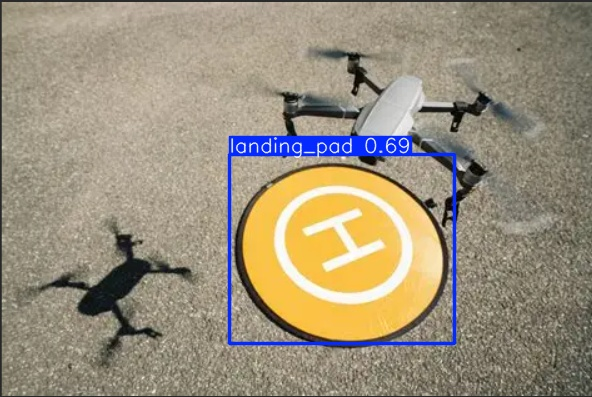

In [46]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display
from pathlib import Path

# seuils (tu peux ajuster)
tau_conf = 0.5
tau_area = 0.03

best_model = YOLO("runs/detect/train/weights/best.pt")

image_path = r"C:\Users\sarah\Desktop\Elisa 5\projet deep learning\test.png"

results = best_model.predict(source=image_path, conf=0.25, save=True)

r = results[0]

decision = "NOT SAFE"

if r.boxes is not None and len(r.boxes) > 0:
    
    h, w = r.orig_shape
    image_area = w * h
    
    for b in r.boxes:
        
        conf = float(b.conf[0])
        
        x1, y1, x2, y2 = b.xyxy[0]
        box_area = (x2 - x1) * (y2 - y1)
        
        area_ratio = box_area / image_area
        
        print("confidence:", conf)
        print("area_ratio:", float(area_ratio))
        
        if conf >= tau_conf and area_ratio >= tau_area:
            decision = "SAFE"

print("Landing decision:", decision)

save_dir = Path(r.save_dir)
saved_files = list(save_dir.glob("*"))

display(Image.open(saved_files[0]))

In [54]:
from ultralytics import YOLO
import cv2

tau_conf = 0.40
tau_area = 0.03

model = YOLO("runs/detect/train/weights/best.pt")

cap = cv2.VideoCapture(0)

window_name = "Drone Landing Decision"
cv2.namedWindow(window_name)

while True:

    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, conf=0.15, verbose=False)
    r = results[0]

    decision = "NOT SAFE"
    best_conf = 0
    best_area_ratio = 0
    best_box = None

    h, w = frame.shape[:2]
    image_area = w * h

    if r.boxes is not None and len(r.boxes) > 0:

        for b in r.boxes:

            conf = float(b.conf[0])
            x1, y1, x2, y2 = map(int, b.xyxy[0])

            box_area = max(0, x2 - x1) * max(0, y2 - y1)
            area_ratio = box_area / image_area

            if conf > best_conf:
                best_conf = conf
                best_area_ratio = area_ratio
                best_box = (x1, y1, x2, y2)

    if best_box is not None:

        x1, y1, x2, y2 = best_box

        if best_conf >= tau_conf and best_area_ratio >= tau_area:
            decision = "SAFE"

        color_box = (0,255,0) if decision=="SAFE" else (0,0,255)

        cv2.rectangle(frame, (x1,y1), (x2,y2), color_box, 2)

        label = f"conf={best_conf:.2f} area={best_area_ratio:.3f}"
        cv2.putText(frame, label,
                    (x1, max(30, y1-10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    color_box,
                    2)

    color_text = (0,255,0) if decision=="SAFE" else (0,0,255)

    cv2.putText(frame, decision,
                (20,50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.2,
                color_text,
                3)

    cv2.imshow(window_name, frame)

    # quitter avec q
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

    # quitter si on ferme la fenêtre
    if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
        break

cap.release()
cv2.destroyAllWindows()